In [ ]:
# =========================================
# REGRESIÓN LINEAL - ÓXIDO NITROSO
# Autor: Juan José Velasco
# Notebook: Correlacion de datos
# =========================================

In [ ]:
# Análisis de Correlaciones

#En este notebook se estudia la relación entre las emisiones de óxido nitroso y las variables ambientales de humedad, temperatura y presión.

#Se empleará principalmente el coeficiente de correlación de Pearson y herramientas gráficas para identificar la intensidad y dirección de las relaciones lineales presentes en la base de datos.

In [1]:
##Importacion de librerias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

sns.set(style="whitegrid")

In [3]:
# Cargar el dataset
df = pd.read_excel("../data/oxido nitroso.xls")


# Renombrar columnas con nombres y unidades
df.columns = [
    "NOx (ppm)",        # Óxido nitroso
    "Humidity (%)",     # Humedad relativa
    "Temp (°C)",        # Temperatura
    "Pressure (inHg)"   # Presión atmosférica
]

#Mostrar todos los datos
df.head(20)

,NOx (ppm),Humidity (%),Temp (°C),Pressure (inHg)
0,0.90,72.4,76.3,29.18
1,0.91,41.6,70.3,29.35
2,0.96,34.3,77.1,29.24
3,0.89,35.1,68.0,29.27
4,1.00,10.7,79.0,29.78
5,1.10,12.9,67.4,29.39
6,1.15,8.3,66.8,29.69
7,1.03,20.1,76.9,29.48
8,0.77,72.2,77.7,29.09
9,1.07,24.0,67.7,29.60


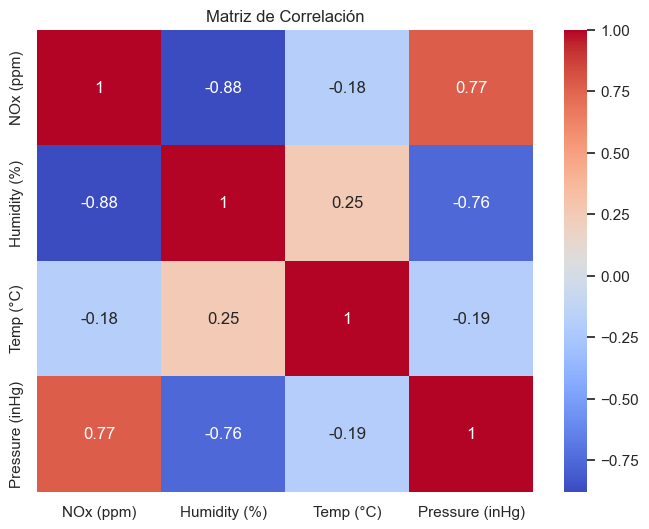

In [5]:
# Matriz de correlación
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlación")
plt.show()

In [ ]:
#Coeficientes de Pearson (r) para cada variable con NOx
variables = [
   
    "Humidity (%)",     # Humedad relativa
    "Temp (°C)",        # Temperatura
    "Pressure (inHg)"   # Presión atmosférica
]

for var in variables:
    
    r, p = pearsonr(df[var], df["NOx (ppm)"])
    
    print(f"{var}")
    print(f"Coeficiente de Pearson: {r:.4f}")
    print(f"Valor-p: {p:.6f}")
    print("-"*40)

Humidity (%)
Coeficiente de Pearson: -0.8774
Valor-p: 0.000000
----------------------------------------
Temp (°C)
Coeficiente de Pearson: -0.1808
Valor-p: 0.445661
----------------------------------------
Pressure (inHg)
Coeficiente de Pearson: 0.7740
Valor-p: 0.000062
----------------------------------------


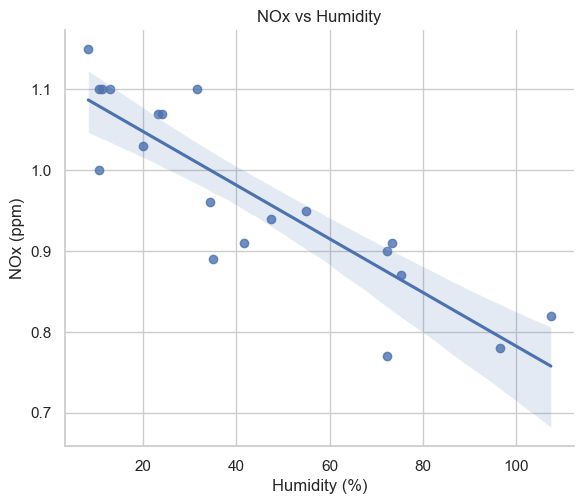

In [ ]:
# Gráfico de dispersión con línea de regresión para Humidity vs NOx
sns.lmplot(
    data=df,
    x="Humidity (%)",
    y="NOx (ppm)",
    height=5,
    aspect=1.2
)

plt.title("NOx vs Humidity")
plt.show()

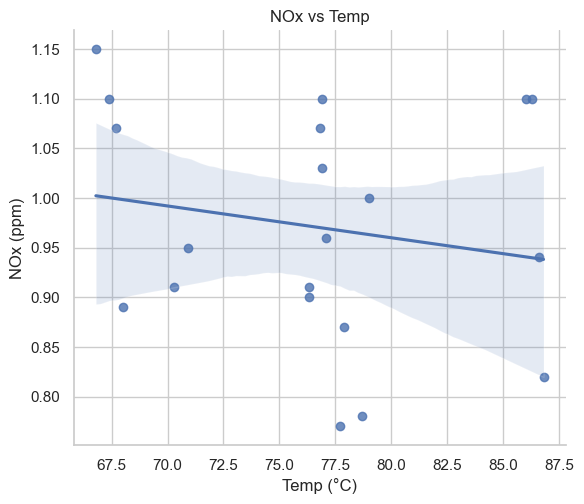

In [ ]:
# Gráfico de dispersión con línea de regresión para Temp vs NOx
sns.lmplot(
    data=df,
    x="Temp (°C)",
    y="NOx (ppm)",
    height=5,
    aspect=1.2
)

plt.title("NOx vs Temp")
plt.show()

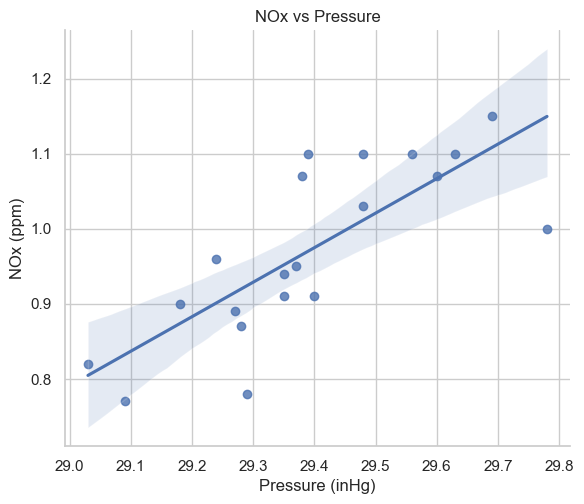

In [ ]:
# Gráfico de dispersión con línea de regresión para Pressure vs NOx   
sns.lmplot(
    data=df,
    x="Pressure (inHg)",
    y="NOx (ppm)",
    height=5,
    aspect=1.2
)

plt.title("NOx vs Pressure")
plt.show()

In [18]:
# Crear ranking de variables por correlación absoluta con NOx
ranking = corr["NOx (ppm)"].drop("NOx (ppm)").abs().sort_values(ascending=False)

ranking

Humidity (%)       0.877364
Pressure (inHg)    0.774008
Temp (°C)          0.180765
Name: NOx (ppm), dtype: float64

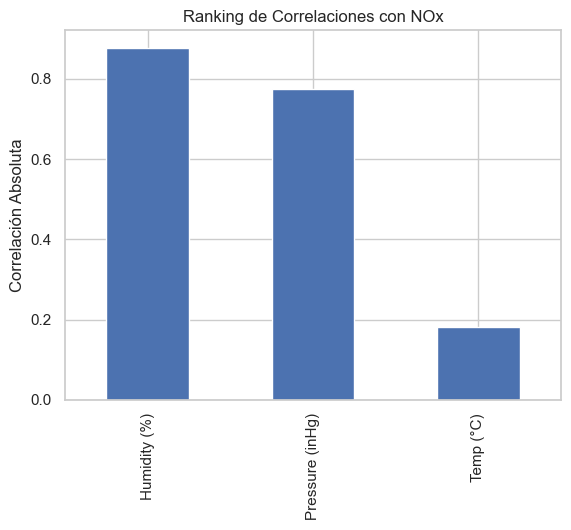

In [17]:
ranking.plot(kind="bar")

plt.title("Ranking de Correlaciones con NOx")
plt.ylabel("Correlación Absoluta")

plt.show()

In [ ]:
# Conclusiones

# La variable Humidity (%) presentó la relación lineal más fuerte con las emisiones de NOx, con un coeficiente de correlación de magnitud aproximada de 0.877.
# La relación entre Humidity (%) y NOx (ppm) es negativa, lo que sugiere que incrementos en la humedad están asociados con disminuciones en las emisiones de óxido nitroso.
# La variable Pressure (inHg) también mostró una relación lineal considerable con las emisiones de NOx, aunque menor que la observada para la humedad.
# La variable Temp (°C) presentó la correlación más baja con NOx, indicando una capacidad explicativa lineal limitada frente a las demás variables ambientales.
# Los diagramas de dispersión y las tendencias observadas sugieren que el uso de modelos de regresión lineal simple es adecuado para continuar el análisis estadístico.